
# Actividad 2 — Pipeline de procesamiento clásico

Este notebook construye, paso a paso, el pipeline de procesamiento de imágenes clásico usado como base
del proyecto (el mismo recorte + redimensionamiento que alimenta las CNN de
`actividad_3_clasificacion_visual_cnn.ipynb`), y además explora suavizado, umbralización y detección de
bordes — operaciones que **no** usa la CNN final (que aprende sus propios filtros), pero que sirven
para entender qué información aporta o pierde cada transformación clásica antes de decidir qué le
conviene a una CNN.

Cada operación es una **transformación parametrizada**: se declaran sus parámetros explícitamente, se
compara contra la imagen original (nunca se sobrescribe) y se explica qué información conserva,
elimina o resalta.



## Checkpoint 0 — Carga sin sobrescribir el original

*(Criterio: "El pipeline conserva una copia de la imagen original")*

Se carga la imagen una sola vez, en BGR (`cv2.imread`), y se guarda inmediatamente una copia en RGB que
se usa como **referencia original** en todas las comparaciones — ninguna operación posterior modifica
`img_original`, todas trabajan sobre copias nuevas.


In [1]:

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml subiendo desde " + str(start))

ROOT = find_repo_root()
IMG_PATH = ROOT / "data" / "Padel_an_2-6" / "test" / "images" / \
    "Punto_1_mp4-0000_jpg.rf.1f2275227317eaa948c1b86fe466e957.jpg"

img_bgr_raw = cv2.imread(str(IMG_PATH))
img_original = cv2.cvtColor(img_bgr_raw, cv2.COLOR_BGR2RGB).copy()  # referencia intocable
print("img_original: shape", img_original.shape, "dtype", img_original.dtype,
      " id() distinto de la lectura cruda:", id(img_original) != id(img_bgr_raw))

def show(imgs, titles, cmap=None, figsize=None):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize or (4.2*n, 4.2))
    if n == 1:
        axes = [axes]
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im, cmap=cmap)
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


img_original: shape (640, 640, 3) dtype uint8  id() distinto de la lectura cruda: True



## Checkpoint 1 — Espacios de color: RGB, escala de grises, HSV y canales por separado

*(Criterio: "Los espacios de color y las dimensiones se manejan correctamente")*

Además de RGB y escala de grises, se agrega **HSV** (Matiz-Saturación-Valor): separa el color (H) de
la iluminación (V), útil para tareas como detectar la cancha azul de forma robusta a cambios de luz —
algo que RGB no permite hacer directamente porque el color queda mezclado con el brillo en los 3
canales. También se muestran los 3 canales de RGB por separado, cada uno como imagen en escala de
grises (intensidad de ese color en cada píxel).


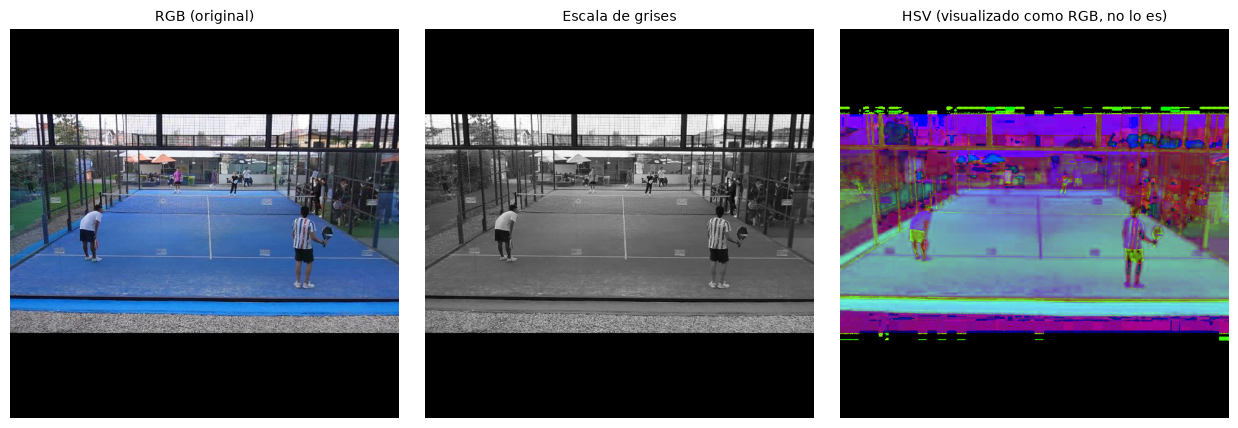

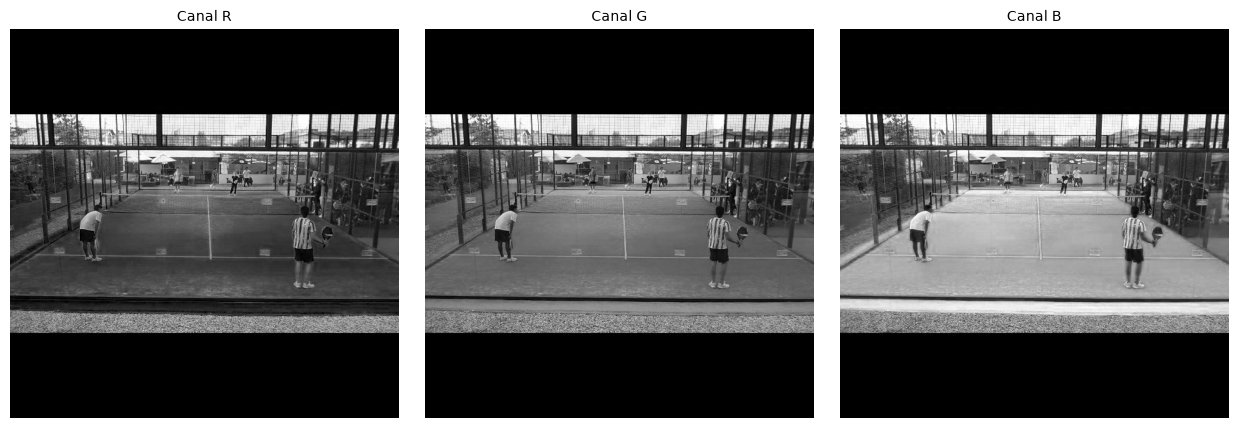

Canal R -> shape (640, 640) (perdió la dimensión de canales, igual que la escala de grises)


In [2]:

img_gray = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)
img_hsv = cv2.cvtColor(img_original, cv2.COLOR_RGB2HSV)

show([img_original, img_gray, img_hsv],
     ["RGB (original)", "Escala de grises", "HSV (visualizado como RGB, no lo es)"],
     cmap="gray")

R, G, B = img_original[:, :, 0], img_original[:, :, 1], img_original[:, :, 2]
show([R, G, B], ["Canal R", "Canal G", "Canal B"], cmap="gray")
print("Canal R -> shape", R.shape, "(perdió la dimensión de canales, igual que la escala de grises)")



## Checkpoint 2 — Redimensionamiento: interpolación seleccionada y justificada

*(Criterio: "La interpolación del redimensionamiento se selecciona y justifica")*

Se reduce la imagen a 1/4 de su tamaño (de 640×640 a 160×160) con 4 interpolaciones distintas para
comparar:

- **`INTER_NEAREST`**: copia el píxel más cercano — rápida pero produce bordes dentados ("bloques").
- **`INTER_LINEAR`** (bilineal): promedia los 4 píxeles vecinos — buen balance calidad/velocidad, es
  la que usa el proyecto real (`Image.BILINEAR` en `actividad_3_clasificacion_visual_cnn.ipynb`) para
  redimensionar los recortes de jugador antes de entrar a la CNN.
- **`INTER_AREA`**: promedia sobre el área completa que colapsa en cada píxel de salida — la
  recomendada por OpenCV específicamente para **reducir** tamaño (menos aliasing que bilineal).
- **`INTER_CUBIC`**: interpolación cúbica (16 vecinos) — mejor calidad, más costosa, pensada más para
  **agrandar** imágenes.

**Elegida para el proyecto**: `INTER_LINEAR`/`BILINEAR`, porque los recortes de jugador son pequeños y
se necesita velocidad para entrenar muchas épocas sobre miles de recortes; a este tamaño la diferencia
de calidad frente a `INTER_AREA` es visualmente mínima.


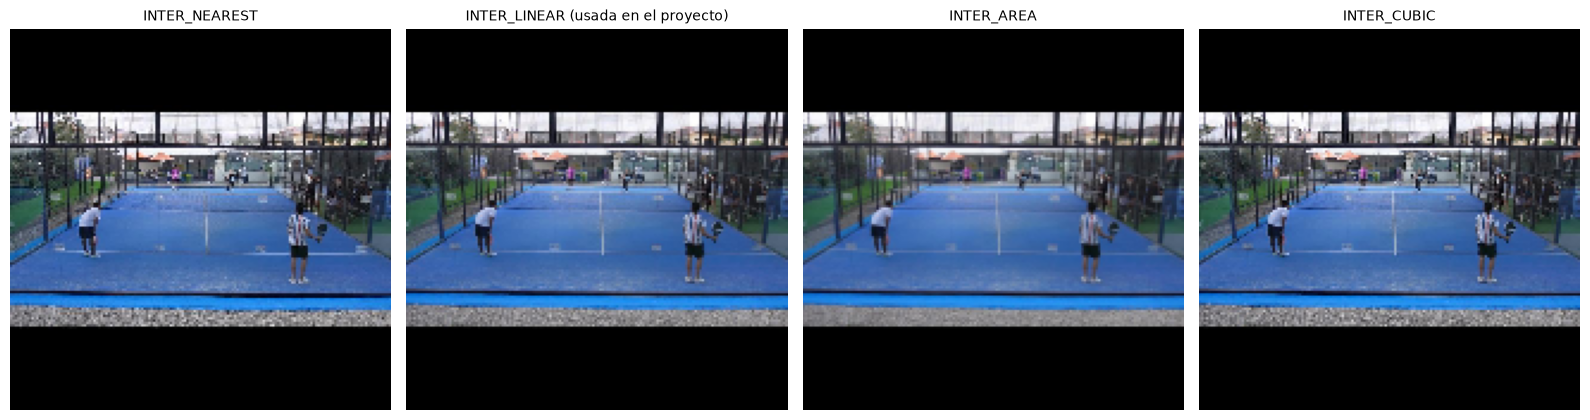

INTER_NEAREST: shape=(160, 160, 3)
INTER_LINEAR (usada en el proyecto): shape=(160, 160, 3)
INTER_AREA: shape=(160, 160, 3)
INTER_CUBIC: shape=(160, 160, 3)


In [3]:

NEW_SIZE = (160, 160)  # (ancho, alto)
metodos = {
    "INTER_NEAREST": cv2.INTER_NEAREST,
    "INTER_LINEAR (usada en el proyecto)": cv2.INTER_LINEAR,
    "INTER_AREA": cv2.INTER_AREA,
    "INTER_CUBIC": cv2.INTER_CUBIC,
}
resized = {name: cv2.resize(img_original, NEW_SIZE, interpolation=flag) for name, flag in metodos.items()}

show(list(resized.values()), list(resized.keys()), figsize=(16, 4.2))
for name, im in resized.items():
    print(f"{name}: shape={im.shape}")



## Checkpoint 3 — Recorte de región de interés (ROI): el mismo usado para la CNN

*(Parte de "dimensiones manejadas correctamente")*

Se recorta al jugador más cercano a cámara usando su bbox anotado más un padding proporcional —
**exactamente la misma regla** que genera los recortes de entrenamiento en
`actividad_3_clasificacion_visual_cnn.ipynb` (0.25× a los lados y arriba, 0.35× hacia abajo, para que
la raqueta —que se extiende más allá de la mano— quede visible).


bbox original: 91x155 px  ->  recorte con padding: 137x248 px


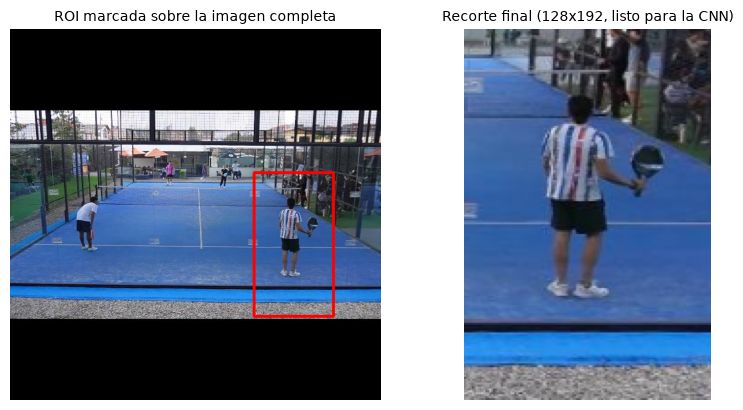

In [4]:

# bbox real del jugador más cercano en esta imagen (label de Punto_1_mp4-0000)
cx, cy, w, h = 0.765625, 0.56875, 0.1421875, 0.2421875
H, W = img_original.shape[:2]

PAD_TOP_FRAC, PAD_BOTTOM_FRAC, PAD_X_FRAC = 0.25, 0.35, 0.25
bbox_top_px, bbox_bot_px = (cy - h/2) * H, (cy + h/2) * H
bbox_left_px, bbox_right_px = (cx - w/2) * W, (cx + w/2) * W
bbox_h_px, bbox_w_px = h * H, w * W

top = max(0, bbox_top_px - PAD_TOP_FRAC * bbox_h_px)
bottom = min(H, bbox_bot_px + PAD_BOTTOM_FRAC * bbox_h_px)
left = max(0, bbox_left_px - PAD_X_FRAC * bbox_w_px)
right = min(W, bbox_right_px + PAD_X_FRAC * bbox_w_px)

roi = img_original[int(top):int(bottom), int(left):int(right)].copy()
print(f"bbox original: {bbox_w_px:.0f}x{bbox_h_px:.0f} px  ->  recorte con padding: {roi.shape[1]}x{roi.shape[0]} px")

roi_resized = cv2.resize(roi, (128, 192), interpolation=cv2.INTER_LINEAR)  # mismo tamaño final que la CNN

img_with_box = img_original.copy()
cv2.rectangle(img_with_box, (int(left), int(top)), (int(right), int(bottom)), (255, 0, 0), 3)
show([img_with_box, roi_resized], ["ROI marcada sobre la imagen completa", "Recorte final (128x192, listo para la CNN)"])



## Checkpoint 4 — Suavizado (Gaussian Blur)

*(Criterio: "Los filtros, umbrales y bordes tienen parámetros explícitos")*

Filtro gaussiano con kernel `(9, 9)` y `sigma=0`(calculado automáticamente a partir del tamaño del
kernel). Reduce ruido de alta frecuencia (textura fina del pasto/red) pero también difumina bordes
finos — un compromiso deliberado antes de operaciones sensibles al ruido como la detección de bordes.


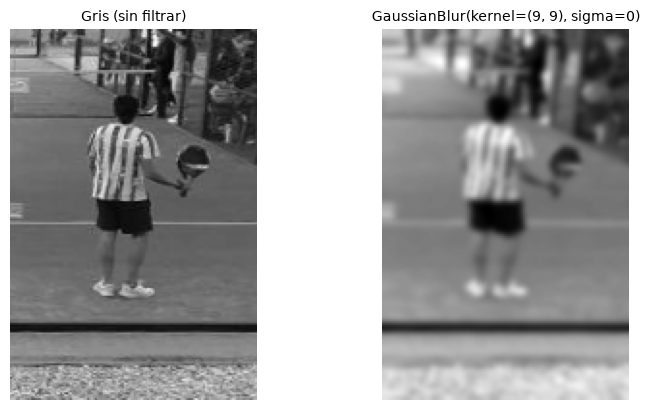

In [5]:

KERNEL, SIGMA = (9, 9), 0
roi_gray = cv2.cvtColor(roi_resized, cv2.COLOR_RGB2GRAY)
roi_blur = cv2.GaussianBlur(roi_gray, KERNEL, SIGMA)

show([roi_gray, roi_blur], [f"Gris (sin filtrar)", f"GaussianBlur(kernel={KERNEL}, sigma={SIGMA})"], cmap="gray")



## Checkpoint 5 — Umbralización (Otsu)

*(Criterio: "Los filtros, umbrales y bordes tienen parámetros explícitos")*

Umbral binario automático de **Otsu** (`cv2.THRESH_OTSU`): en vez de fijar un umbral a mano, el
algoritmo elige el valor que mejor separa dos poblaciones de intensidad (fondo vs. jugador/objetos) —
se aplica sobre la versión suavizada para no umbralizar ruido de píxel a píxel. Conserva **solo** la
silueta (forma), eliminando toda la información de color y textura interna.


umbral elegido automáticamente por Otsu: 79 (de 0-255)


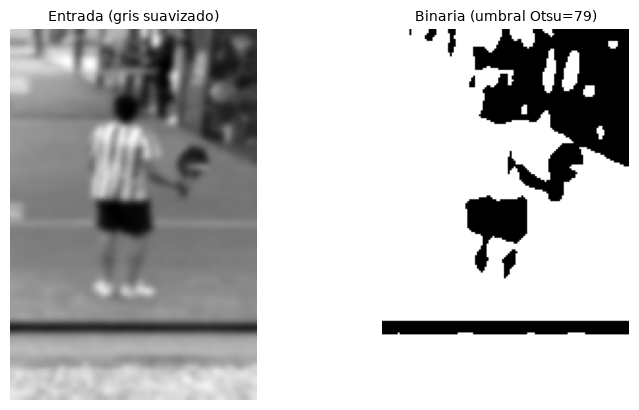

In [6]:

umbral_otsu, roi_thresh = cv2.threshold(roi_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"umbral elegido automáticamente por Otsu: {umbral_otsu:.0f} (de 0-255)")

show([roi_blur, roi_thresh], ["Entrada (gris suavizado)", f"Binaria (umbral Otsu={umbral_otsu:.0f})"], cmap="gray")



## Checkpoint 6 — Detección de bordes (Canny)

*(Criterio: "Los filtros, umbrales y bordes tienen parámetros explícitos")*

`cv2.Canny` con umbrales explícitos `(low=50, high=150)` sobre la versión suavizada (aplicar Canny sin
suavizar antes genera bordes espurios por ruido). Conserva únicamente los contornos de alto contraste
(silueta del jugador, líneas de la cancha, red) y descarta toda la información de superficie/color.


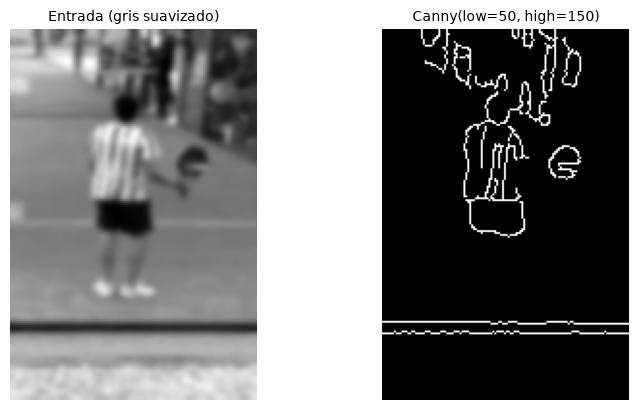

In [7]:

LOW, HIGH = 50, 150
roi_edges = cv2.Canny(roi_blur, LOW, HIGH)

show([roi_blur, roi_edges], ["Entrada (gris suavizado)", f"Canny(low={LOW}, high={HIGH})"], cmap="gray")



## Checkpoint 7 — Conclusiones: qué conserva, elimina o resalta cada operación

*(Criterio: "Las conclusiones explican información conservada, eliminada o resaltada")*

| Operación | Conserva | Elimina | Resalta |
|---|---|---|---|
| RGB → Grises | Forma, brillo, textura | Color (matiz/saturación) | Contraste de luminancia |
| RGB → HSV | Toda la información de color | — (es una reproyección, no pérdida) | Separa color (H) de iluminación (V) |
| Canales R/G/B por separado | Solo la intensidad de ese color | Los otros 2 canales | Qué tan "roja/verde/azul" es cada zona |
| Resize (BILINEAR) | Forma general, proporciones | Detalle fino de alta frecuencia | — |
| Recorte (ROI) | Todo el detalle del jugador | Contexto/fondo de la cancha | El sujeto de interés |
| Suavizado (Gaussian) | Formas grandes, tendencia general | Ruido y textura fina | — |
| Umbral (Otsu) | Silueta/forma binaria | Color, textura, gradientes suaves | El contorno objeto vs. fondo |
| Bordes (Canny) | Contornos de alto contraste | Superficies uniformes, color | Líneas y siluetas |



## Checkpoint 8 — Propuesta de preprocesamiento para clasificación (CNN)

*(Criterio: "La propuesta de preprocesamiento se vincula con una tarea de visión")*

La tarea real del proyecto es **clasificación** (tipo de keypoint, en
`actividad_3_clasificacion_visual_cnn.ipynb`) mediante una CNN entrenada de punta a punta. El
preprocesamiento propuesto —y el que efectivamente usa el proyecto— es:

1. **Recorte de ROI** (Checkpoint 3): aísla al jugador, reduciendo el tamaño de entrada y evitando que
   la CNN tenga que aprender a ignorar fondo variable de cancha/publicidad/espectadores.
2. **Redimensionamiento bilineal** a un tamaño fijo (128×192 o 48×48 según el modelo): las CNN
   necesitan tensores de tamaño constante por lote.
3. **Normalización a `float32` en [0,1]** (o estandarizada con media/desvío de train, ver
   Actividad 1): estabiliza el entrenamiento.
4. Se mantiene **RGB a color, sin escala de grises, sin umbral, sin bordes**: una CNN aprende sus
   propios filtros (equivalentes a los que armamos a mano acá) directamente de los datos, y el color es
   señal útil para distinguir keypoints (p. ej. piel vs. ropa vs. cancha) — convertir a bordes/umbral
   *antes* de la CNN tiraría información que el modelo sí puede aprovechar.

**Si la tarea fuera distinta** (p. ej. *segmentación* del jugador contra la cancha, o *detección* de la
línea de la cancha), sí tendría sentido usar Otsu/Canny como parte del pipeline final, o incluso como
features clásicas de apoyo — la elección de qué transformaciones conservar depende de la tarea, no es
una receta fija.



## Checkpoint 9 — Verificación: el notebook corre de principio a fin

*(Criterio: "El notebook puede ejecutarse de principio a fin sin pasos ocultos")*

Todas las celdas de este notebook son autocontenidas y dependen solo de `img_original` (Checkpoint 0) y
del bbox declarado explícitamente en el Checkpoint 3 — no hay variables cargadas desde otro notebook ni
estado oculto. `Restart & Run All` reproduce exactamente estos resultados.
